<a href="https://colab.research.google.com/github/nataliagdorado/MachineLearningMenstrualIrregularities/blob/main/Notebook_2_Experimental_design_and_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. EXPERIMENTAL DESIGN
The code implemented was following the tutorial of scikit-learn: https://scikit-learn.org/stable/modules/cross_validation.html

## 1.1. Data loading and inspection



In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

ruta_archivo1 = '/content/drive/MyDrive/BIASBUSTERS PYTHON/cleanDatasetMenstrual.csv'
ruta_archivo2 = '/content/drive/MyDrive/BIASBUSTERS PYTHON/TransformedMenstrualDataSetLog&Norm.csv'

print("Cargando archivos desde Google Drive...")

df1 = pd.read_csv(ruta_archivo1, sep=';')
df2 = pd.read_csv(ruta_archivo2, sep=';')

print("Shape df1:", df1.shape)
print("Shape df2:", df2.shape)

Cargando archivos desde Google Drive...
Shape df1: (10000, 17)
Shape df2: (10000, 17)


## 1.2. Preprocessing and defining the target
The column `life_stage` is object type, but Python models doesn't understand the text, only numbers. So we convert that attribute.
In the last lines we define the target from the rest of variables

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold


# Encoding 'life_stage'
le = LabelEncoder()
df1 = df1.copy()
df1['life_stage_encoded'] = le.fit_transform(df1['life_stage'])

# Removing the original text column to avoid errors
df1_model = df1.drop('life_stage', axis=1)

# Defining X and y (duration_abnormality_flag is the target)
y1 = df1_model['duration_abnormality_flag']
X1 = df1_model.drop('duration_abnormality_flag', axis=1)

# Setting up 10-fold stratified cv with seed 42 to keep it consistent
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Preprocessing del Primer CSV (df1) completado.")
print(f"Tamaño de X1: {X1.shape}")
print(f"Tamaño de y1: {y1.shape}")

Preprocessing del Primer CSV (df1) completado.
Tamaño de X1: (10000, 16)
Tamaño de y1: (10000,)


About the prints, the first one "   - 'life_stage' encoded mappings: `{'adolescent': np.int64(0), 'perimenopausal': np.int64(1), 'reproductive': np.int64(2)}`" means that the integers are now 0, 1 and 2 for life_stage. And the second print confirm the dimension of the xplot: the feature matrix, X, have 10.000 samples with 16 variables. And the target vector, y, has 10.000 class labels.

## 1.3. Experimental design
Our dataset presents a significant class imbalance: only 16.6% of the samples represent menstrual irregularities

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, make_scorer

def clinical_cost_loss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel() # ravel aplasta una matrix para hacerla de una sola fila, se convierte en una lista seguida

    # Definimos los pesos del 4.2 (FP=1, FN=10)
    cost_fp = 1
    cost_fn = 10

    return (fp * cost_fp) + (fn * cost_fn)

# definimos el scorer. greater_is_better=False porque queremos que el coste sea bajo (minimizar), no alto
cost_scorer = make_scorer(clinical_cost_loss, greater_is_better=False)


To evaluate model performance in a medical context, we defined a custom Cost Matrix. We prioritized sensitivity by assigning a penalty of 10 to False Negatives (missing an anomaly), compared to a penalty of 1 for False Positives. We use a 10-fold stratified cross-validation strategy.

Cost Matrix:


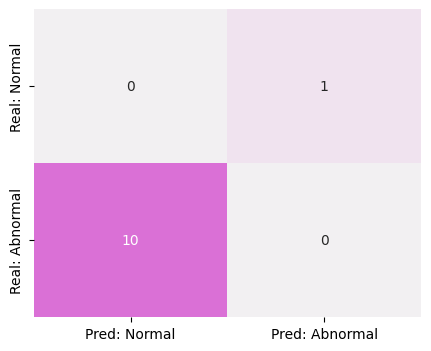

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# FOR VISUALIZE
cost_data = [[0, 1], [10, 0]]
cost_matrix_df = pd.DataFrame(cost_data,
                              columns=['Pred: Normal', 'Pred: Abnormal'],
                              index=['Real: Normal', 'Real: Abnormal'])

print("Cost Matrix:")
plt.figure(figsize=(5,4))
cmap_rosita = sns.light_palette("orchid", as_cmap=True)
sns.heatmap(cost_matrix_df, annot=True, cmap=cmap_rosita, cbar=False, fmt='d')
plt.show()

# 2. MODEL TRAINING
*The following text is from our report, Chapter 5:*

In this chapter, we do the core part of the Project Model Training and Specification.
*   Accuracy-Trained Models: This is our starting point, where models are trained to achieve the highest possible overall success rate. In this standard approach, every classification error is treated as having the same weight.
*   Cost-Trained Models: Here, we move into a more "real-world" clinical scenario. Based on the Cost Matrix defined in our experimental design (Section 1.3), we prioritize patient safety by training models to minimize the total clinical penalty.

The key concept driving this chapter is that accuracy is not always the best metric for medical decisions. As we explored in the theory, the most effective model for our purpose might not be the one with the fewest mistakes, but rather the one whose mistakes have the lowest clinical impact.


## 2.1.Decision trees




### 2.1.2. Accuracy-Trained Decision Trees




In [ ]:
numeric_cols = [ #importante "ignorar" la variable nominal: life_stage
    "avg_bleeding_days",
    "bleeding_volume_score",
    "cubicCycleVarCoeff",
    "cubicCycleLengthVar",
    "age",
    "bmi",
    "tracking_duration_months",
    "pain_score",
    "cubicAvgCycleLength",
    "cubicIntermenstrualEps",
    "pattern_disruption_score",
    "Oligomenorrhea",
    "Polymenorrhea",
    "Menorrhagia",
    "Amenorrhea"
]
x=df2[numeric_cols]#variables utilizadas para la prediccion
y=df2['duration_abnormality_flag'] #Variable objetivo =label

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)#separacion del dataset en: 80% para entrenamiento y 20% para testear

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_impurity_decrease=0.1,
    min_samples_leaf=1,
    random_state=42
)

dt_model.fit(X_train,y_train)


DecisionTreeClassifier(max_depth=5, min_impurity_decrease=0.1, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_dt=dt_model.predict(X_test)
accuracy_dt=accuracy_score(y_test, y_pred_dt)

print("The accuracy of the test set is:", accuracy_dt)


The accuracy of the test set is: 0.946


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
from scipy import stats

cvScores_dt = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)

print("The Cross Validation Scores over the training data are:", cvScores_dt)

cvMean_dt = cvScores_dt.mean()
cvStd_dt = cvScores_dt.std()

print("The mean of the Scores obtained before is:", cvMean_dt)
print("The standard deviation of the Scores obtained before is:", cvStd_dt)


The Cross Validation Scores over the training data are: [0.9475  0.94375 0.95875 0.95    0.955   0.93375 0.9625  0.95375 0.95375
 0.94875]
The mean of the Scores obtained before is: 0.95075
The standard deviation of the Scores obtained before is: 0.007689278249614857


In [ ]:
#CONFIDENCE INTERVAL
n = len(cvScores_dt)
confidence = 0.95

tCritical = stats.t.ppf((1 + confidence) / 2, df=n - 1)
marginErr = tCritical * (cvStd_dt / np.sqrt(n))

ciLower_dt = cvMean_dt - marginErr
ciUpper_dt = cvMean_dt + marginErr

print(
    "The confidence interval computed with a confidence of 95% over the cross validation scores is:",
    round(ciLower_dt, 4),
    round(ciUpper_dt, 4)
)

The confidence interval computed with a confidence of 95% over the cross validation scores is: 0.9452 0.9563


### 2.1.2 Cost- Trained Decision Tree

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


numeric_cols = [
    "avg_bleeding_days",
    "bleeding_volume_score",
    "cubicCycleVarCoeff",
    "cubicCycleLengthVar",
    "age",
    "bmi",
    "tracking_duration_months",
    "pain_score",
    "cubicAvgCycleLength",
    "cubicIntermenstrualEps",
    "pattern_disruption_score",
    "Oligomenorrhea",
    "Polymenorrhea",
    "Menorrhagia",
    "Amenorrhea"
]

X = df2[numeric_cols]
y = df2["duration_abnormality_flag"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


classes_global = np.sort(y.unique())
n_classes = len(classes_global)

C = np.array([
    [0, 1],
    [10, 0]
], dtype=float)

assert C.shape == (n_classes, n_classes), "La cost matrix no coincide con el nº de clases."


def make_dt():
    return DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_impurity_decrease=0.1,
        min_samples_leaf=1,
        random_state=42
    )

def cost_based_predict(proba: np.ndarray, cost_matrix: np.ndarray):

    expected_cost = proba @ cost_matrix
    pred_idx = expected_cost.argmin(axis=1)
    return pred_idx, expected_cost

def mean_cost(y_true_idx: np.ndarray, y_pred_idx: np.ndarray, cost_matrix: np.ndarray):
    return cost_matrix[y_true_idx, y_pred_idx].mean()



skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_acc = []
fold_cost = []

for tr, te in skf.split(X, y):
    X_train, X_test = X.iloc[tr], X.iloc[te]
    y_train, y_test = y.iloc[tr], y.iloc[te]

    dt_model = make_dt()
    dt_model.fit(X_train, y_train)

    proba = dt_model.predict_proba(X_test)

    classes = dt_model.classes_
    class_to_idx = {c: i for i, c in enumerate(classes)}

    y_true_idx = y_test.map(class_to_idx).to_numpy()

    y_pred_idx, _ = cost_based_predict(proba, C)
    y_pred = classes[y_pred_idx]

    acc = accuracy_score(y_test, y_pred)
    cost = mean_cost(y_true_idx, y_pred_idx, C)

    fold_acc.append(acc)
    fold_cost.append(cost)



fold_acc = np.array(fold_acc)
fold_cost = np.array(fold_cost)

print("The Cross Validation Accuracy Scores over the data are:", fold_acc)
print("The mean of the Accuracy scores obtained before is:", fold_acc.mean())
print("The standard deviation of the Accuracy scores obtained before is:", fold_acc.std())

print("\n")

print("The Cross Validation Cost Scores over the data are:", fold_cost)
print("The mean of the Cost scores obtained before is:", fold_cost.mean())
print("The standard deviation of the Cost scores obtained before is:", fold_cost.std())


The Cross Validation Accuracy Scores over the data are: [0.972 0.962 0.932 0.944 0.943 0.954 0.947 0.94  0.948 0.956]
The mean of the Accuracy scores obtained before is: 0.9498
The standard deviation of the Accuracy scores obtained before is: 0.010961751684835768


The Cross Validation Cost Scores over the data are: [0.091 0.137 0.239 0.2   0.174 0.19  0.179 0.159 0.178 0.161]
The mean of the Cost scores obtained before is: 0.1708
The standard deviation of the Cost scores obtained before is: 0.03707775613491194


## 2.2. Rule based models


In order to build a Rule-based model with Python, first we imported the necessary functions and then prepared the data. We performed a 10-Fold Cross Validation, which divided the data in 10 parts using 9 of these to train the model and the remaining part to test it.
Then we proceeded to evaluate the data. First, we created a function that splits the data into training and testing, trains the model, makes predictions and computes the accuracy.

In [ ]:
from sklearn.tree import export_text
from sklearn.model_selection import KFold

In [ ]:
# We generate the following function what we will use when computing the mean cost per fold
def calculate_mean_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # cm[0,1] is False Positives (Normal predicted as Abnormal)
    # cm[1,0] is False Negatives (Abnormal predicted as Normal)
    fp = cm[0, 1] if cm.shape == (2, 2) else 0
    fn = cm[1, 0] if cm.shape == (2, 2) else 0

    total_cost = (fn * 10) + (fp * 1)
    return total_cost / len(y_true)

In [ ]:
# We drop "life_stage" so we only work with "life_stage_encoded" and we do not get any errors
X = df1.drop(columns=['duration_abnormality_flag', 'pattern_disruption_score', 'life_stage'])
y = df1['duration_abnormality_flag']

# We define a 10-fold cross validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# We created a function tht performs the data evaluation. This funciton receives 4 parameters
def evaluate_model(model, X, y, title):
    # We create an empty list of accuracies where the accuracies of each fold will be stored
    fold_accuracies = []
    # We create an empty list to store cost per fold
    fold_costs = []
    print(f"\n----- {title} -----\n")

    # For that iterates as many times as folds the cross vlaidation has (10)
    for i, (train_index, test_index) in enumerate(kf.split(X)):
      # The data is splitted intro training and testing data.
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        # We train the model and make predictions using the fit and predict functions respectively
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # We compute the accuracy of the fold that is being iterated
        acc = accuracy_score(y_test, y_pred)
        # We add the computed accuracy to the list of accuracies
        fold_accuracies.append(acc)

        # We compute the accuracy of the fold that is being iterated
        cost = calculate_mean_cost(y_test, y_pred)
        # We add the computed accuracy to the list of accuracies
        fold_costs.append(cost)

        # We output the accuracies and the mean cost per fold
        print(f"Fold {i+1}: {acc*100:.2f}% | Mean Cost: {cost:.4f}")
    # Additionally, we compute the average of accuracies and costs making use of the mean function and computing it over the list of accuracies and costs respectively
    print(f"\nAverage Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
    print(f"\nAverage Mean Cost: {np.mean(fold_costs):.4f}")

    # Fit on full data for the final rules
    model.fit(X, y)
    return export_text(model, feature_names=list(X.columns))

### 2.2.1 Accuracy-Trained Architecture

Regarding the Accuracy-Trained Rule-based model, it prioritizes having the smaller amount of errors (both FN and FP which are seen as the same in the sense of cost). Therefore, the code below focuses of achieving a model with very high accuracy.

In [ ]:
# We will use "DecisionTreeClassifier" to compute the Rule-Based Model
model_accuracy = DecisionTreeClassifier(
    criterion='gini', # Gini Impurity is used to decide the best split points
    max_depth=4, # We are limitting the depth to 4 levels to ensure the produced rules are readable
    min_samples_leaf=50, # We are preventing the model from creating rules for tiny groups
    random_state=42 # We are freezing the randomness in such a way that, every time we run the code, the computer makes the same random choices
)
# We call the function we created and store its returned value in "rules_acc"
rules_acc = evaluate_model(model_accuracy, X, y, "RULE-BASED MODEL: ACCURACY TRAINED")
print("Accuracy Model Rules:\n", rules_acc)


----- RULE-BASED MODEL: ACCURACY TRAINED -----

Fold 1: 98.30% | Mean Cost: 0.0890
Fold 2: 97.70% | Mean Cost: 0.1760
Fold 3: 98.00% | Mean Cost: 0.1460
Fold 4: 98.40% | Mean Cost: 0.0880
Fold 5: 98.80% | Mean Cost: 0.0930
Fold 6: 97.10% | Mean Cost: 0.2360
Fold 7: 98.40% | Mean Cost: 0.1240
Fold 8: 97.80% | Mean Cost: 0.1570
Fold 9: 98.80% | Mean Cost: 0.0750
Fold 10: 98.00% | Mean Cost: 0.1100

Average Accuracy: 98.13%

Average Mean Cost: 0.1294
Accuracy Model Rules:
 |--- cycle_length_variation <= 0.00
|   |--- Menorrhagia <= 0.50
|   |   |--- avg_bleeding_days <= 2.55
|   |   |   |--- class: 1
|   |   |--- avg_bleeding_days >  2.55
|   |   |   |--- class: 1
|   |--- Menorrhagia >  0.50
|   |   |--- avg_bleeding_days <= 7.50
|   |   |   |--- avg_bleeding_days <= 4.55
|   |   |   |   |--- class: 1
|   |   |   |--- avg_bleeding_days >  4.55
|   |   |   |   |--- class: 0
|   |   |--- avg_bleeding_days >  7.50
|   |   |   |--- avg_bleeding_days <= 8.50
|   |   |   |   |--- class: 1
|  

### 2.2.2 Cost-Trained Architecture

In [ ]:
# According to the cost matrix we configured before, the weights of the errors are:
# False Negative (Abnormal predicted as Normal) = 10
# False Positive (Normal predicted as Abnormal) = 1
# By setting these weights to the error we are telling the model that missing an abnormal patient is
# 10 times more expensive than missing a normal patient.

# We use "DecisionTreeClassifier" to create the Rule-Based Model whose result is stored in the variable "model_cost"
model_cost = DecisionTreeClassifier(
    criterion='gini', # Gini Impurity is used to decide the best split points
    max_depth=4, # We are limitting the depth to 4 levels to ensure the produced rules are readable
    min_samples_leaf=50, # We are preventing the model from creating rules for tiny groups
    random_state=42, # We are freezing the randomness in such a way that, every time we run the code, the computer makes the same random choices
    class_weight={0: 1, 1: 10} # We introduce the weights of making errors of each class
)
# We call the funciton we created before and store its returned value in "rules_cost"
rules_cost = evaluate_model(model_cost, X, y, "RULE-BASED MODEL: COST TRAINED")
print("Cost Model Rules:\n", rules_cost)


----- RULE-BASED MODEL: COST TRAINED -----

Fold 1: 95.50% | Mean Cost: 0.0630
Fold 2: 95.30% | Mean Cost: 0.0740
Fold 3: 95.30% | Mean Cost: 0.0560
Fold 4: 95.40% | Mean Cost: 0.0460
Fold 5: 96.70% | Mean Cost: 0.0330
Fold 6: 94.60% | Mean Cost: 0.0900
Fold 7: 95.70% | Mean Cost: 0.0520
Fold 8: 94.20% | Mean Cost: 0.0760
Fold 9: 94.90% | Mean Cost: 0.0510
Fold 10: 95.00% | Mean Cost: 0.0770

Average Accuracy: 95.26%

Average Mean Cost: 0.0618
Cost Model Rules:
 |--- cycle_length_variation <= 0.00
|   |--- Menorrhagia <= 0.50
|   |   |--- avg_bleeding_days <= 2.55
|   |   |   |--- class: 1
|   |   |--- avg_bleeding_days >  2.55
|   |   |   |--- class: 1
|   |--- Menorrhagia >  0.50
|   |   |--- avg_bleeding_days <= 7.50
|   |   |   |--- avg_bleeding_days <= 4.55
|   |   |   |   |--- class: 1
|   |   |   |--- avg_bleeding_days >  4.55
|   |   |   |   |--- class: 1
|   |   |--- avg_bleeding_days >  7.50
|   |   |   |--- avg_bleeding_days <= 8.50
|   |   |   |   |--- class: 1
|   |   |  

## 2.3. Naive-bayes




Following notebook 4 done and uploaded to Github by our professor, we developed Naive Bayes in Python to enhance our project.
As specified in the aforementioned notebook, it is not possible to apply Naive-Bayes to both numerical and nominal variables all at once, which forced us to transform one of these types of attributes to the other. We decided to transform ordinal attributes to numerical, making use of "GaussianNB" and "LabelEncoder".
In addition, as stated with more detail in the report, we removed both the label and the feature "pattern_distribution_score" since the later presented a very high correlation with another feature and we wanted to avoid data duplication so that the assumption regarding the attributes being independent, which is what characterises Naive-Bayes, was satisfied.

In [ ]:
# We import the necessary funcitons
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

In [ ]:
gnb = GaussianNB() # We create a gaussian classifier
# We encode the categorical attribute "life_sage" into numerical format for the model
le = LabelEncoder()
# In order to compute the Naive Bayes model, we use the dataset that was already normalized
df2['life_stage'] = le.fit_transform(df2['life_stage'])

# We drop redundant features to ensure accuracy of the model and the label
X = df2.drop(columns=['duration_abnormality_flag', 'pattern_disruption_score'])
y = df2['duration_abnormality_flag']

### 2.3.1 Accuracy-Trained Architecture

The model built below focuses on achieving the highest value of accuracy, meaning that aims to compute as many right guesses as possible.

In [ ]:
# This first experiment represents the real-world distribution where normal cases are the vast majority.
print("----- NAIVE BAYES EXPERIMENT 1: UNBALANCED -----\n")
# We perform a 10-fold cross-validation and obtain the accuracy results
result = cross_val_score(gnb, X, y, cv=10, scoring='accuracy')

# We decided to go further in the analysis and perform a Classification Report as well as the Confusion Matrix
y_pred_1 = cross_val_predict(gnb, X, y, cv=10)
classReport = classification_report(y, y_pred_1, target_names=['Normal', 'Abnormal'])
print("\n--- Naive Bayes Classification Report ---")
print(classReport)

print("--- Confusion Matrix ---")
print(confusion_matrix(y, y_pred_1))

# We print the accuracy of each fold using a for loop
print("\n--- Accuracy per Fold ---")
for i, acc in enumerate(result):
    print(f"Fold {i+1}: {acc*100:.2f}%")

print(f"\nMax Accuracy: Fold {result.argmax()+1} ({result.max()*100:.2f}%)")
print(f"Min Accuracy: Fold {result.argmin()+1} ({result.min()*100:.2f}%)")

# We compute the KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
# We create an empty list to store the mean cost of every fold
unbalanced_costs = []

print("--- Naive Bayes Experiment 1: Cost per Fold ---")
for i, (train_idx, test_idx) in enumerate(kf.split(X)):
  # We divide the data into training and testing data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # We train the model and make predictions over the original (unbalanced) dataset
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    # We obtain the cost of the fold and add it to the list of costs
    fold_cost = clinical_cost_loss(y_test, y_pred)
    unbalanced_costs.append(fold_cost)
    #Finally, we output the mean cost per value alongside the average mean cost.
    print(f"Fold {i+1} Mean Cost: {fold_cost:.4f}")

print(f"Average Mean Cost (Unbalanced): {np.mean(unbalanced_costs):.4f}")

print("\n\n----- NAIVE BAYES EXPERIMENT 2: 50/50 BALANCED -----\n")
# We separate the classes
df_normal = df2[df2.duration_abnormality_flag == 0]
df_abnormal = df2[df2.duration_abnormality_flag == 1]

# We downsample the majority class (Normal) without replacement
df_normal_50 = resample(df_normal, replace=False, n_samples=len(df_abnormal), random_state=42)
df_5050 = pd.concat([df_normal_50, df_abnormal])

X_2 = df_5050.drop(columns=['duration_abnormality_flag', 'pattern_disruption_score'])
y_2 = df_5050['duration_abnormality_flag']

# We are enabling the model to learn from the reduced balanced dataset (X_2 and y_2)
gnb.fit(X_2, y_2)
# We are making the predictions over the whole (original unbalanced) datatset (the one used in experiment 1)
y_2_final = gnb.predict(X)

print("\n--- Naive Bayes Classification Report ---")
print(classification_report(y, y_2_final, target_names=['Normal', 'Abnormal']))

print("--- Confusion Matrix ---")
print(confusion_matrix(y, y_2_final))

# The third experiment forces the model to have many more abnormal cases than normal ones in order to enhance abnormality detection.
print("\n\n----- NAIVE BAYES EXPERIMENT 3: 80% ABNORMAL / 20% NORMAL -----\n")
num_normal_needed = int(len(df_abnormal) * 0.25)
df_normal_20 = resample(df_normal, replace=False, n_samples=num_normal_needed, random_state=42)
df_8020 = pd.concat([df_normal_20, df_abnormal])

X_3 = df_8020.drop(columns=['duration_abnormality_flag', 'pattern_disruption_score'])
y_3 = df_8020['duration_abnormality_flag']

# We are enabling the model to learn from the reduced balanced dataset (X_2 and y_2)
gnb.fit(X_3, y_3)
# We are making the predictions over the whole datatset (the one used in experiment 1)
y_3_final = gnb.predict(X)

print("\n--- Naive Bayes Classification Report ---")
print(classification_report(y, y_3_final, target_names=['Normal', 'Abnormal']))

print("--- Confusion Matrix ---")
print(confusion_matrix(y, y_3_final))

----- NAIVE BAYES EXPERIMENT 1: UNBALANCED -----


--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.96      8337
    Abnormal       0.76      0.95      0.84      1663

    accuracy                           0.94     10000
   macro avg       0.88      0.94      0.90     10000
weighted avg       0.95      0.94      0.94     10000

--- Confusion Matrix ---
[[7843  494]
 [  85 1578]]

--- Accuracy per Fold ---
Fold 1: 94.50%
Fold 2: 92.00%
Fold 3: 93.60%
Fold 4: 94.70%
Fold 5: 94.60%
Fold 6: 93.60%
Fold 7: 95.70%
Fold 8: 95.30%
Fold 9: 94.00%
Fold 10: 94.10%

Max Accuracy: Fold 7 (95.70%)
Min Accuracy: Fold 2 (92.00%)
--- Naive Bayes Experiment 1: Cost per Fold ---
Fold 1 Mean Cost: 147.0000
Fold 2 Mean Cost: 173.0000
Fold 3 Mean Cost: 122.0000
Fold 4 Mean Cost: 132.0000
Fold 5 Mean Cost: 158.0000
Fold 6 Mean Cost: 137.0000
Fold 7 Mean Cost: 126.0000
Fold 8 Mean Cost: 138.0000
Fold 9 Mean Cost: 92.0000

### 2.3.2 Cost-Trained Architecture

Once again, the cost-trained model built below focuses on decreasing the amount of FN even if that implies having more FP and, therefore, a lower accuracy.

In [ ]:
# We simulate the 10:1 cost matrix by adjusting the 'priors' parameter.
# We assign a much higher prior probability to the Abnormal class (index 1).
# [Normal Priority, Abnormal Priority]
gnb_cost = GaussianNB(priors=[0.1, 0.9])

print("\n\n----- NAIVE BAYES COST-TRAINED: 80% ABNORMAL / 20% NORMAL -----\n")
# We run the 10-fold cross-validation and store the result in the variable "cost_result"
cost_result = cross_val_score(gnb_cost, X, y, cv=10, scoring='accuracy')

print("--- Accuracy per Fold (Cost-Trained) ---")
for i, acc in enumerate(cost_result):
  # We print each fold accuracy separately
    print(f"Fold {i+1}: {acc*100:.2f}%")

print(f"\nAverage Accuracy: {cost_result.mean()*100:.2f}% (+/- {cost_result.std()*100:.2f}%)")
print(f"Max Accuracy: Fold {cost_result.argmax()+1} ({cost_result.max()*100:.2f}%)")
print(f"Min Accuracy: Fold {cost_result.argmin()+1} ({cost_result.min()*100:.2f}%)")

# We compute the KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
# We create an empty list to store the mean cost of every fold
unbalanced_costs = []

print("--- Naive Bayes Experiment 3: Cost per Fold ---")
for i, (train_idx, test_idx) in enumerate(kf.split(X)):
  # We divide the data into training and testing data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # We train the model and make predictions over the original (unbalanced) dataset
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    # We obtain the cost of the fold and add it to the list of costs
    fold_cost = clinical_cost_loss(y_test, y_pred)
    unbalanced_costs.append(fold_cost)
    #Finally, we output the mean cost per value alongside the average mean cost.
    print(f"Fold {i+1} Mean Cost: {fold_cost:.4f}")

print(f"Average Mean Cost (Unbalanced): {np.mean(unbalanced_costs):.4f}")


# We use "cross_val_predict" to see how the cost-sensitive model handles the whole (original unbalanced) dataset
y_pred_cost = cross_val_predict(gnb_cost, X, y, cv=10)

print("\n--- Naive Bayes Cost-Trained Classification Report ---")
print(classification_report(y, y_pred_cost, target_names=['Normal', 'Abnormal']))

print("--- Confusion Matrix (Cost-Trained) ---")
print(confusion_matrix(y, y_pred_cost))

# We are enabling the model to learn from the reduced balanced dataset (X_2 and y_2)
gnb_cost.fit(X_3, y_3)
# We are making the predictions over the whole datatset (the one used in experiment 1)
y_3_final = gnb_cost.predict(X)



----- NAIVE BAYES COST-TRAINED: 80% ABNORMAL / 20% NORMAL -----

--- Accuracy per Fold (Cost-Trained) ---
Fold 1: 68.50%
Fold 2: 68.00%
Fold 3: 69.10%
Fold 4: 69.30%
Fold 5: 70.50%
Fold 6: 71.00%
Fold 7: 71.10%
Fold 8: 72.00%
Fold 9: 70.30%
Fold 10: 70.20%

Average Accuracy: 70.00% (+/- 1.19%)
Max Accuracy: Fold 8 (72.00%)
Min Accuracy: Fold 2 (68.00%)
--- Naive Bayes Experiment 3: Cost per Fold ---
Fold 1 Mean Cost: 147.0000
Fold 2 Mean Cost: 173.0000
Fold 3 Mean Cost: 122.0000
Fold 4 Mean Cost: 132.0000
Fold 5 Mean Cost: 158.0000
Fold 6 Mean Cost: 137.0000
Fold 7 Mean Cost: 126.0000
Fold 8 Mean Cost: 138.0000
Fold 9 Mean Cost: 92.0000
Fold 10 Mean Cost: 122.0000
Average Mean Cost (Unbalanced): 134.7000

--- Naive Bayes Cost-Trained Classification Report ---
              precision    recall  f1-score   support

      Normal       0.99      0.65      0.78      8337
    Abnormal       0.35      0.95      0.51      1663

    accuracy                           0.70     10000
   macro a

## 2.4. Bayesian Network


In order to apply Bayesian Network, we had to include the "pgmpy" library and discretize some variables.


In [ ]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 40.2 MB/s eta 0:00:00


In [ ]:
# We import the necessary functions
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

In [ ]:
# We create a copy of the dataset
data_bn = df1.copy()

# Ensure categorical life_stage is numerical since Bayesian Networks require categorical or numerical inputs.
if data_bn['life_stage'].dtype == 'object': # If "life_stage" is text, we convert it to numbers
    le = LabelEncoder()
    data_bn['life_stage'] = le.fit_transform(data_bn['life_stage'])

# Bayesian Networks require discrete data.
# We bin continuous variables into 4 categories.
for col in data_bn.columns:
    if data_bn[col].dtype != 'object' and len(data_bn[col].unique()) > 10:
        data_bn[col] = pd.cut(data_bn[col], bins=4, labels=[0, 1, 2, 3])

# We define the structure
# Age affects life stage, and life stage + BMI affect the abnormality flag.
model_structure = [
    ('age', 'life_stage'),
    ('life_stage', 'duration_abnormality_flag'),
    ('bmi', 'duration_abnormality_flag'),
    ('pain_score', 'duration_abnormality_flag'),
    ('avg_bleeding_days', 'duration_abnormality_flag')
]
# We configure the 10-Fold Cross-Validaton for statistical reliability
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# We create a function that computes the threashold,
def run_bn_experiment(cost_mode=False, title=""):
    print(f"\n{title}")
    print("-" * len(title))
    # We generate an empty list where the accuracies of each fold will be stored
    fold_accuracies = []
    # We create an empty list to store cost per fold
    fold_costs = []

    # 10:1 Cost Ratio threshold
    # Cost(FN)=10, Cost(FP)=1 -> Threshold = 1 / (10+1) = ~0.09
    cost_threshold = 1 / (10 + 1)
    # We generate a for loop that iterates as many times as folds the cross-vlaidation has
    for i, (train_idx, test_idx) in enumerate(kf.split(data_bn)):
      # We separate the data into train and test data
        train_data = data_bn.iloc[train_idx]
        test_data = data_bn.iloc[test_idx]
        # We intialize and train the model using "MaximumLikelihoodEstimator"
        # MLE computes the probability of an outcome based on how often it appears in the training data
        model = DiscreteBayesianNetwork(model_structure)
        model.fit(train_data, estimator=MaximumLikelihoodEstimator)

        X_test = test_data[['age', 'life_stage', 'bmi', 'pain_score', 'avg_bleeding_days']]
        y_true = test_data['duration_abnormality_flag'].astype(int)

        if not cost_mode:
            # ACCURACY MODE: Standard prediction with the original unbalanced dataset
            y_pred_df = model.predict(X_test)
            y_pred = y_pred_df['duration_abnormality_flag'].astype(int)
        else:
            # COST MODE: Probability-based prediction
            # We get probabilities for each class
            y_prob = model.predict_probability(X_test)
            # We predict 'Abnormal' (1) if the probability is higher than our cost threshold
            y_pred = (y_prob['duration_abnormality_flag_1'] >= cost_threshold).astype(int)
        # We compute the accuracy of the fold and add it to the list of accuracies
        acc = accuracy_score(y_true, y_pred)
        fold_accuracies.append(acc)
        # We compute the cost of the fold and add it to the list of costs
        cost = calculate_mean_cost(y_true, y_pred)
        fold_costs.append(cost)
        # We output both the accuracy and the mean cost of the fold
        print(f"Fold {i+1} Accuracy: {acc*100:.2f}% | Mean Cost: {cost:.4f}")

    # We output both the average accuracy and the average cost
    print(f"\nAverage Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
    print(f"\nAverage Mean Cost: {np.mean(fold_costs):.4f}")
    return y_true, y_pred

### 2.4.1 Accuracy-Trained Architecture

As seen before in the previous model, the accuracy-trained ones prioritize having the largest possible amount of right guesses without caring about what type or cost the mistakes they make have (to them, FP and FN have the same cost).

In [ ]:
# Standard model aiming for maximum overall accuracy.
run_bn_experiment(cost_mode=False, title="BAYESIAN NETWORK: ACCURACY-TRAINED")


BAYESIAN NETWORK: ACCURACY-TRAINED
----------------------------------


/usr/local/lib/python3.12/dist-packages/pgmpy/models/DiscreteBayesianNetwork.py:720: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_unique_indexes = data.groupby(list(data.columns), dropna=False).apply(


  0%|          | 0/228 [00:00<?, ?it/s]

Fold 1 Accuracy: 95.40% | Mean Cost: 0.1810


/usr/local/lib/python3.12/dist-packages/pgmpy/models/DiscreteBayesianNetwork.py:720: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_unique_indexes = data.groupby(list(data.columns), dropna=False).apply(


...

Fold 9 Accuracy: 96.20% | Mean Cost: 0.1730


/usr/local/lib/python3.12/dist-packages/pgmpy/models/DiscreteBayesianNetwork.py:720: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_unique_indexes = data.groupby(list(data.columns), dropna=False).apply(


  0%|          | 0/216 [00:00<?, ?it/s]

Fold 10 Accuracy: 96.00% | Mean Cost: 0.1840

Average Accuracy: 95.82%

Average Mean Cost: 0.1966


(4       1
 5       0
 9       0
 55      0
 64      1
        ..
 9955    1
 9978    0
 9981    0
 9982    1
 9987    0
 Name: duration_abnormality_flag, Length: 1000, dtype: int64,
 4       0
 5       0
 9       0
 55      0
 64      0
        ..
 9955    1
 9978    0
 9981    0
 9982    1
 9987    0
 Name: duration_abnormality_flag, Length: 1000, dtype: int64)

### 2.4.2 Cost-Trained Architecture

On the other hand, this cost-trained model will show a decrease in FN (which are the mistakes that have a greater cost) even if it implies a decrease in accuracy due to an increase in the less expensive mistakes (FP).

In [ ]:
# Clinical model aiming to minimize missed abnormalities
run_bn_experiment(cost_mode=True, title="BAYESIAN NETWORK: COST-TRAINED")


BAYESIAN NETWORK: COST-TRAINED
------------------------------
Fold 1 Accuracy: 94.50% | Mean Cost: 0.1720
Fold 2 Accuracy: 95.00% | Mean Cost: 0.2030
Fold 3 Accuracy: 95.90% | Mean Cost: 0.1670
Fold 4 Accuracy: 95.80% | Mean Cost: 0.1320
Fold 5 Accuracy: 96.70% | Mean Cost: 0.1410
Fold 6 Accuracy: 94.30% | Mean Cost: 0.2550
Fold 7 Accuracy: 96.20% | Mean Cost: 0.1910
Fold 8 Accuracy: 94.20% | Mean Cost: 0.2560
Fold 9 Accuracy: 96.40% | Mean Cost: 0.1350
Fold 10 Accuracy: 95.20% | Mean Cost: 0.1740

Average Accuracy: 95.42%

Average Mean Cost: 0.1826


(4       1
 5       0
 9       0
 55      0
 64      1
        ..
 9955    1
 9978    0
 9981    0
 9982    1
 9987    0
 Name: duration_abnormality_flag, Length: 1000, dtype: int64,
 4       0
 5       0
 9       0
 55      0
 64      0
        ..
 9955    1
 9978    0
 9981    0
 9982    1
 9987    0
 Name: duration_abnormality_flag_1, Length: 1000, dtype: int64)

## 2.5.Support Vector machine

In [ ]:
numeric_cols = [ #importante "ignorar" la variable nominal: life_stage
    "avg_bleeding_days",
    "bleeding_volume_score",
    "cubicCycleVarCoeff",
    "cubicCycleLengthVar",
    "age",
    "bmi",
    "tracking_duration_months",
    "pain_score",
    "cubicAvgCycleLength",
    "cubicIntermenstrualEps",
    "pattern_disruption_score",
    "Oligomenorrhea",
    "Polymenorrhea",
    "Menorrhagia",
    "Amenorrhea"
]
x=df2[numeric_cols]#variables utilizadas para la prediccion
y=df2['duration_abnormality_flag'] #Variable objetivo =label

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)#separacion del dataset en: 80% para entrenamiento y 20% para testear


In [ ]:
from sklearn.svm import SVC

svm_model = SVC( #suppor vector machine de clasificación
    kernel="rbf",#tipo de kernel que permite fronteras NO lineales
    C=1, #Control de equilibrio entre un margen grande y los errores
    gamma="scale",#influencia de cada punto
    random_state=42
)

svm_model.fit(X_train, y_train) #el modelo aprende: identificación support vectors + maximizacion margen + frontera de decision

SVC(C=1, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("The accuracy of the test set is: ",accuracy)#rendimiento real sobre los datos de test (cantidad de clasificación)

The accuracy of the test set is:  0.972


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
from scipy import stats

cvScores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)#cross validation: entrenamiento y validacion 5 veces
#cross validation: asses the performance of machine learning models by evaluating their ability to generalize
#unseen data to prevent overfitting and ensuring the model's validation.

print("The Cross Validation Scores over the training data are: ",cvScores)

cvMean=cvScores.mean()#media de validacion
cvStd=cvScores.std()#desviacion de la validacion
print("The mean of the Scores obtained before is: ",cvMean)
print("The standar deviation of the Scores obtained before is: ",cvStd)

#computation of the Confidence Interval:
n=len(cvScores)
confidence=0.95
tCritical=stats.t.ppf((1+confidence)/2, df=n-1)
marginErr=tCritical * (cvStd/np.sqrt(n))

ciLower=cvMean-marginErr
ciUpper=cvMean+marginErr

confInterval=[ciLower,ciUpper]

print("The confidence interval commputed with a confidence of 95% over the cross validation scores is: ", round(confInterval[0], 4), round(confInterval[1], 4))

The Cross Validation Scores over the training data are:  [0.96875 0.97    0.97125 0.97    0.975   0.95625 0.9775  0.9725  0.96875
 0.9675 ]
The mean of the Scores obtained before is:  0.96975
The standar deviation of the Scores obtained before is:  0.005356071321407128
The confidence interval commputed with a confidence of 95% over the cross validation scores is:  0.9659 0.9736


In [ ]:
#CONFUSION MATRIX:

from sklearn.metrics import confusion_matrix

confMatrix=confusion_matrix (y_test, y_pred)
confMatrix

array([[1633,   34],
       [  22,  311]])

## 2.6. Neural Networks and Deep Learning
Following the GitHub codes [4_PredictiveModels](https://github.com/AbrahamOtero/MLiB/blob/main/4_PredictiveModels.ipynb) and [5_IssuesTrainingNetworks](https://github.com/AbrahamOtero/MLiB/blob/main/4.5_IssuesTrainingNeuralNetworks.ipynb) we're going to apply the neural network model. We do a layer evolution to find the optimal balance between complexity and generalization.
The reasons where:
*    Control over overfitting. By manually design, we could use regularization techniques (Dropout 0.3) exactly where needed.

*   Model interpretation: We stated with a defined baseline (model 0) and we increased the complexity (model 1 with two hidden layers and model two with 3 hidden layers and a dropout).
We used X_train_scaled to normalize our features, ensuring the network learns efficiently without being biased by different scales.

We decided to skip logarithmic transformations because our variables didn't show significant asymmetry, so standard scaling was enough for the models to generalize well

### 2.6.1. Accuracy-Trained Architectures

#### Standard Neural Network (Baseline)
Following Teacher's Notebook 4, we stablish a baseline using MLPClassifier

In [ ]:
import tensorflow as tf
from keras import layers, models

tf.keras.utils.set_random_seed(42)

Standard baseline accuracy: 97.94% +/- 0.48%
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      8337
    Abnormal       0.94      0.94      0.94      1663

    accuracy                           0.98     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.98      0.98      0.98     10000

Total clinical cost (Baseline): 1160 points
Mean cost per instance: 0.1160


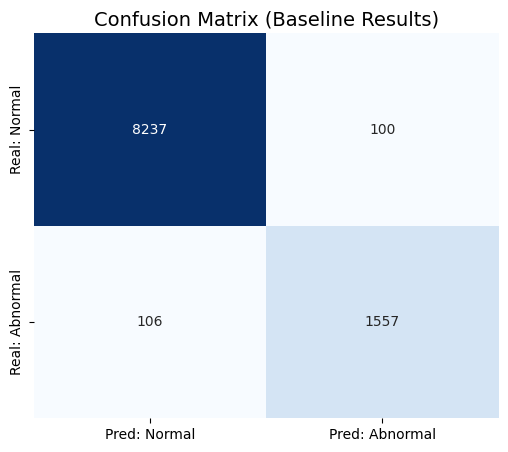

--- Accuracy per Fold (Standard Baseline) ---
Fold 1: 98.20%
Fold 2: 98.50%
Fold 3: 97.90%
Fold 4: 98.10%
Fold 5: 97.60%
Fold 6: 97.80%
Fold 7: 97.90%
Fold 8: 98.00%
Fold 9: 98.60%
Fold 10: 96.80%

Max Accuracy: Fold 9 (98.60%)
Min Accuracy: Fold 10 (96.80%)


In [12]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# simple baseline: 1 hidden layer with 10 neurons
# we use a pipeline for scaling to avoid data leakage during cv
mlp_baseline = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
)

# calculating accuracy and sd
# CAMBIO: Usamos X1 y y1
scores = cross_val_score(mlp_baseline, X1, y1, cv=cv_strategy, scoring='accuracy')

# we generate predictions by c validation to have the performance vector
# CAMBIO: Usamos X1 y y1
y_pred_cv = cross_val_predict(mlp_baseline, X1, y1, cv=cv_strategy)

# CAMBIO: Usamos y1
print(f"Standard baseline accuracy: {scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}%")
print(classification_report(y1, y_pred_cv, target_names=['Normal', 'Abnormal']))
cm = confusion_matrix(y1, y_pred_cv)

# i call to the function of the 1.3. section of this notebook.
# we will use this in next chapter
# CAMBIO: Usamos y1
total_cost_baseline = clinical_cost_loss(y1, y_pred_cv)

print(f"Total clinical cost (Baseline): {total_cost_baseline} points")
# CAMBIO: Usamos len(y1)
print(f"Mean cost per instance: {total_cost_baseline / len(y1):.4f}")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Normal', 'Pred: Abnormal'],
            yticklabels=['Real: Normal', 'Real: Abnormal'])
plt.title('Confusion Matrix (Baseline Results)', fontsize=14)
plt.show()

print("--- Accuracy per Fold (Standard Baseline) ---")
for i, acc in enumerate(scores):
    print(f"Fold {i+1}: {acc*100:.2f}%")

# max min
print(f"\nMax Accuracy: Fold {scores.argmax()+1} ({scores.max()*100:.2f}%)")
print(f"Min Accuracy: Fold {scores.argmin()+1} ({scores.min()*100:.2f}%)")

#### Two hidden layers. Deep learning with Keras.
Following GitHub 5_DeepLearning, we studied Deep Learning approach using the Keras/TensorFlow library. For the model's convergence, we made the following decisions:


*   For the hidden layers: We selected ReLU (Rectified Linear Unit) function. Is computationally efficcient and helps to decrease the "vanishing gradient".
*   For the output layer, we used the sigmoid function. Since our target is binary (`duration_abnormality_flag`), Sigmoid is the standard.
* We used adam eith default parameters instead the others proposed in the Notebook 5 (sgd and rmsprop) because it can automatically adjust the learning rate during training.
* Loss function: We minimized `binary_crossentroply`









Total clinical cost (Model 1 - Keras Two Hudden layers): 443 points
Mean cost per instance: 0.1477
Single Run Accuracy: 97.53%
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      2501
    Abnormal       0.93      0.92      0.93       499

    accuracy                           0.98      3000
   macro avg       0.96      0.95      0.96      3000
weighted avg       0.98      0.98      0.98      3000



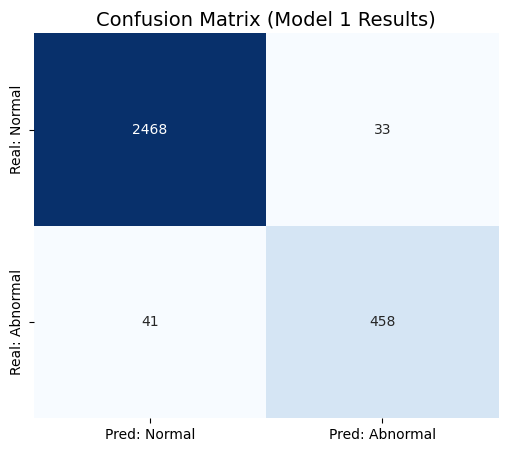

Fold 1: 98.30%
Fold 2: 98.60%
Fold 3: 98.00%
Fold 4: 98.20%
Fold 5: 98.00%
Fold 6: 98.00%
Fold 7: 98.20%
Fold 8: 97.80%
Fold 9: 98.40%
Fold 10: 96.70%

Keras Model 1 (10-Fold CV) Mean Accuracy: 98.02%
Standard Deviation: +/- 0.4915


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# manual Split and scale
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.3, random_state=42, stratify=y1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# my model trained once
model_1_single = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_1_single.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_1_single.fit(
    X_train_scaled, y_train,
    epochs=40, batch_size=32, validation_split=0.1, verbose=0
)

# report an predictions
y_pred_single = (model_1_single.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")
loss, acc_single = model_1_single.evaluate(X_test_scaled, y_test, verbose=0)

# costs
total_cost_single = clinical_cost_loss(y_test, y_pred_single)
print(f"Total clinical cost (Model 1 - Keras Two Hudden layers): {total_cost_single} points")
print(f"Mean cost per instance: {total_cost_single / len(y_test):.4f}")

print(f"Single Run Accuracy: {acc_single*100:.2f}%")
print(classification_report(y_test, y_pred_single, target_names=['Normal', 'Abnormal']))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred_single)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Normal', 'Pred: Abnormal'],
            yticklabels=['Real: Normal', 'Real: Abnormal'])
plt.title('Confusion Matrix (Model 1 Results)', fontsize=14)
plt.show()
# ------------------------

######## TEN FOLD VALIDATION
fold_accuracies = []

for i, (train_index, test_index) in enumerate(cv_strategy.split(X1, y1)):

    # Split
    X_train_fold, X_test_fold = X1.iloc[train_index], X1.iloc[test_index]
    y_train_fold, y_test_fold = y1.iloc[train_index], y1.iloc[test_index]

    # Scale
    scaler_fold = StandardScaler()
    X_train_fold_s = scaler_fold.fit_transform(X_train_fold)
    X_test_fold_s = scaler_fold.transform(X_test_fold)

    # Define NEW model (Reset weights)
    model_cv = Sequential([
        Input(shape=(X_train_fold_s.shape[1],)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model_cv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train
    model_cv.fit(X_train_fold_s, y_train_fold, epochs=40, batch_size=32, verbose=0)

    # Evaluate
    score = model_cv.evaluate(X_test_fold_s, y_test_fold, verbose=0)[1]
    fold_accuracies.append(score)

    print(f"Fold {i+1}: {score*100:.2f}%")

    #RESUMEN
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f"\nKeras Model 1 (10-Fold CV) Mean Accuracy: {mean_acc*100:.2f}%")
print(f"Standard Deviation: +/- {std_acc*100:.4f}")

#### Three hidden layers+dropout
To see if more complexity improves the results, we designed a deeper architecture with an additional layer and a regularization technique. Dropout: We added a Dropout layer (0.3). This is a regularization technique that randomly "turns off" 30% of neurons during training to prevent the model from memorizing the data (overfitting).

--- Keras Model 2 - Dropout) ---
Keras 3-Layers (Dropout) Single Run Accuracy: 97.50%
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      2501
    Abnormal       0.94      0.91      0.92       499

    accuracy                           0.97      3000
   macro avg       0.96      0.95      0.95      3000
weighted avg       0.97      0.97      0.97      3000

Total clinical cost (Model 2): 498 points
Mean cost per instance: 0.1660


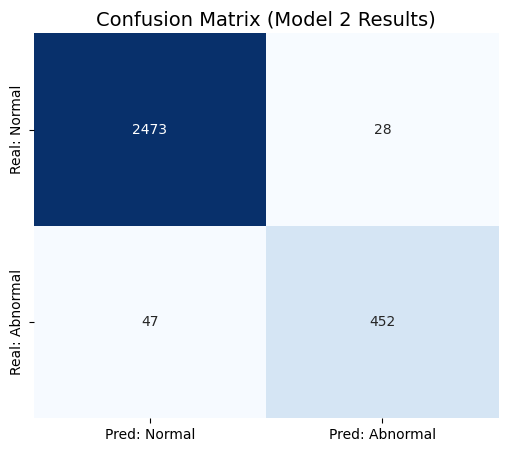


---10-Fold Cross Validation (Generating data for T-Test) ---
Fold 1: 98.50%
Fold 2: 98.50%
Fold 3: 97.80%
Fold 4: 98.20%
Fold 5: 97.70%
Fold 6: 98.00%
Fold 7: 98.20%
Fold 8: 97.60%
Fold 9: 98.40%
Fold 10: 97.20%

Final Keras Model 2 (CV) Mean Accuracy: 98.01%
Standard Deviation: +/- 0.4085


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("--- Keras Model 2 - Dropout) ---")

# split manual (70/30) solo para ver el reporte una vez
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.3, random_state=42, stratify=y1)

# scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Defining Model 2: Deeper with Dropout
model_2_single = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3), # Regularization to avoid overfitting
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_2_single.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Guardamos el entrenamiento en 'history_2', lo utilizo en las leaning curves del final
history_2 = model_2_single.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# training
model_2_single.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# predictions for performance vector
y_pred_k2_single = (model_2_single.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")
loss, acc_single_k2 = model_2_single.evaluate(X_test_scaled, y_test, verbose=0)

# PRINTS SINGLE RUN
print(f"Keras 3-Layers (Dropout) Single Run Accuracy: {acc_single_k2*100:.2f}%")
print(classification_report(y_test, y_pred_k2_single, target_names=['Normal', 'Abnormal']))

# calculating clinical cost for this run
total_cost_k2 = clinical_cost_loss(y_test, y_pred_k2_single)
print(f"Total clinical cost (Model 2): {total_cost_k2} points")
print(f"Mean cost per instance: {total_cost_k2 / len(y_test):.4f}")

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred_k2_single)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Normal', 'Pred: Abnormal'],
            yticklabels=['Real: Normal', 'Real: Abnormal'])
plt.title('Confusion Matrix (Model 2 Results)', fontsize=14)
plt.show()
# ------------------------

print("\n---10-Fold Cross Validation (Generating data for T-Test) ---")

fold_scores_k2 = []

# Looping through the 10 folds defined in cv_strategy
for i, (train_index, test_index) in enumerate(cv_strategy.split(X1, y1)):

    # Split indices for this fold
    X_train_fold, X_test_fold = X1.iloc[train_index], X1.iloc[test_index]
    y_train_fold, y_test_fold = y1.iloc[train_index], y1.iloc[test_index]

    # Scale  - Avoiding data leakage
    scaler_fold = StandardScaler()
    X_train_fold_s = scaler_fold.fit_transform(X_train_fold)
    X_test_fold_s = scaler_fold.transform(X_test_fold)

    # Define Model 2 AGAIN (We need a fresh model for each fold)
    model_cv = Sequential([
        Input(shape=(X_train_fold_s.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.3), # Regularization
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_cv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train
    model_cv.fit(X_train_fold_s, y_train_fold, epochs=50, batch_size=32, verbose=0)

    # Save accuracy
    score = model_cv.evaluate(X_test_fold_s, y_test_fold, verbose=0)[1]
    fold_scores_k2.append(score)

    print(f"Fold {i+1}: {score*100:.2f}%")

# RESULTADOS ESTADÍSTICOS FINALES
mean_acc_2 = np.mean(fold_scores_k2)
std_acc_2 = np.std(fold_scores_k2)

print(f"\nFinal Keras Model 2 (CV) Mean Accuracy: {mean_acc_2*100:.2f}%")
print(f"Standard Deviation: +/- {std_acc_2*100:.4f}")

Important: All models in this section have a high accuracy (above 97%). However, they are all "Accuracy-Trained," meaning they treat a missed abnormality as equal to a false alarm. In the next section (Notebook 3, 2.6.2), we will re-train these same architectures using our Cost Matrix to see if we can reduce the clinical risk further.

### 2.6.2. Cost-Trained Architectures
For Standard Neural Network, MLPClassifier doesn't allow to introduce weights, so we continue with the part of deep learning.
However, we calculate the cost for the baseline and the two models using the same logic.


#### Two hidden layers

Data ready. X_train shape: (8000, 16)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras 2-Layers Accuracy: 96.70%

--- PERFORMANCE VECTOR: KERAS MODEL 1 (COST-TRAINED) ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      1667
    Abnormal       0.85      0.98      0.91       333

    accuracy                           0.97      2000
   macro avg       0.92      0.97      0.94      2000
weighted avg       0.97      0.97      0.97      2000

Total clinical cost (Model 1): 138 points
Mean cost per instance: 0.0690

Confusion Matrix del modelo entrenado:


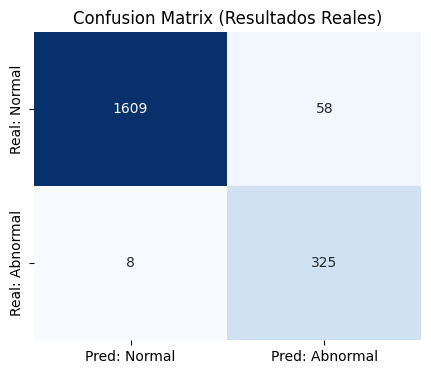

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 1: Accuracy: 98.30% | Mean Cost: 0.0800


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 2: Accuracy: 97.90% | Mean Cost: 0.0570


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

fold 8: Accuracy: 95.60% | Mean Cost: 0.0890


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 9: Accuracy: 96.60% | Mean Cost: 0.0430


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 10: Accuracy: 96.40% | Mean Cost: 0.0900


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import StratifiedKFold


# Hacemos un split simple (80/20) para probar el modelo rápido
# usamos stratify=y1 para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

# Scaling: Neural networks work better with scaled data (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data ready. X_train shape: {X_train_scaled.shape}")


# architecture: simple 2-layer network
model_1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)), # layer 1
    Dense(16, activation='relu'),                                         # layer 2
    Dense(1, activation='sigmoid')                                        # output
])

# compile with standard binary loss
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# training with our clinical cost matrix (1:10) Vuelvo a definir aqui la cost matrix por brevedad y para evitar conflictos con el codigo
# Here we apply the weights! 10x penalty for class 1 errors to reduce False Negatives
weights = {0: 1, 1: 10}

history_1 = model_1.fit(
    X_train_scaled, y_train,
    epochs=40,
    batch_size=32,
    class_weight=weights,
    validation_split=0.1,
    verbose=0
)

# evaluation and sd
loss, acc_1 = model_1.evaluate(X_test_scaled, y_test, verbose=0)
mean_acc_1 = acc_1
std_acc_1 = 0.0 # single run has no std deviation yet

# predictions for performance vector
y_pred_1 = (model_1.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")

print(f"Keras 2-Layers Accuracy: {mean_acc_1*100:.2f}%")

print("\n--- PERFORMANCE VECTOR: KERAS MODEL 1 (COST-TRAINED) ---")
print(classification_report(y_test, y_pred_1, target_names=['Normal', 'Abnormal']))

# Usamos tu función de coste definida anteriormente
total_cost_1 = clinical_cost_loss(y_test, y_pred_1)
print(f"Total clinical cost (Model 1): {total_cost_1} points")
print(f"Mean cost per instance: {total_cost_1 / len(y_test):.4f}")


#matriz de lo que ha predicho el modelo
cm = confusion_matrix(y_test, y_pred_1)
cm_df = pd.DataFrame(cm,
                     columns=['Pred: Normal', 'Pred: Abnormal'],
                     index=['Real: Normal', 'Real: Abnormal'])

print("\nConfusion Matrix del modelo entrenado:")
plt.figure(figsize=(5,4))

sns.heatmap(cm_df, annot=True, cmap="Blues", cbar=False, fmt='d')
plt.title("Confusion Matrix (Resultados Reales)")
plt.show()


# -10-FOLD CROSS VALIDATION --

# Convertimos a numpy si son DataFrames para evitar problemas de indexación
X1_np = X1.values if hasattr(X1, 'values') else X1
y1_np = y1.values if hasattr(y1, 'values') else y1

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_no = 1

for train_index, test_index in skf.split(X1_np, y1_np):
    # Separación de datos por fold
    X_train_fold, X_test_fold = X1_np[train_index], X1_np[test_index]
    y_train_fold, y_test_fold = y1_np[train_index], y1_np[test_index]

    # Escalado dentro del fold (para evitar data leakage)
    scaler_cv = StandardScaler()
    X_train_fold_scaled = scaler_cv.fit_transform(X_train_fold)
    X_test_fold_scaled = scaler_cv.transform(X_test_fold)

    # Re-creamos la arquitectura del modelo
    model_cv = Sequential([
        Dense(32, activation='relu', input_shape=(X_train_fold_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_cv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Entrenamos
    model_cv.fit(
        X_train_fold_scaled, y_train_fold,
        epochs=40,
        batch_size=32,
        class_weight=weights,
        verbose=0
    )

# CALCULO DEL COSTE PER FOLD

    y_pred_fold = (model_cv.predict(X_test_fold_scaled, verbose=0) > 0.5).astype("int32")
    fold_total_cost = clinical_cost_loss(y_test_fold, y_pred_fold)
    fold_mean_cost = fold_total_cost / len(y_test_fold)


    # Evaluación
    _, accuracy = model_cv.evaluate(X_test_fold_scaled, y_test_fold, verbose=0)

    print(f"fold {fold_no}: Accuracy: {accuracy*100:.2f}% | Mean Cost: {fold_mean_cost:.4f}")
    fold_no += 1

#### Three hidden layers + Dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Result (accuracy): 96.40%
------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98      1667
    Abnormal       0.83      0.98      0.90       333

    accuracy                           0.96      2000
   macro avg       0.91      0.97      0.94      2000
weighted avg       0.97      0.96      0.97      2000

------------------------------
Total clinical cost (Model 2): 126 points
Mean cost per instance: 0.0630


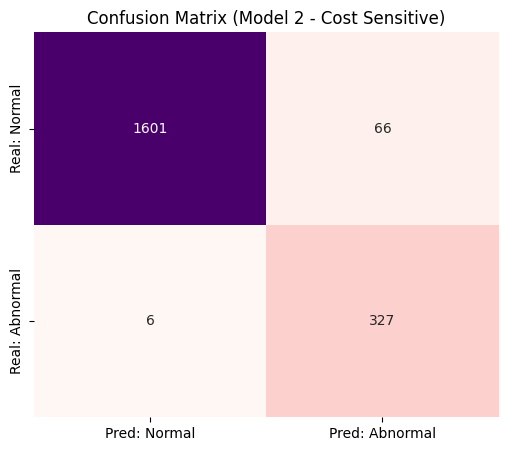

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 1: 98.10% | Mean Cost: 0.0730


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 2: 97.60% | Mean Cost: 0.0600


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

fold 8: 95.60% | Mean Cost: 0.1070


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 9: 96.90% | Mean Cost: 0.0400


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


fold 10: 96.30% | Mean Cost: 0.1180


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np

# separamos train y test del primer dataset (X1, y1)
# uso stratify para que haya la misma proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

# escalamos los datos para que la red neuronal no se confunda  con valores muy distintos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 1 architecture (deeper + regularization)
# we add 3 layers and dropout to make the model more robust
model_2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)), # layer 1

    # dropout: we turn off 30% of neurons to avoid overfitting
    Dropout(0.3),

    Dense(32, activation='relu'),  # layer 2
    Dense(16, activation='relu'),  # layer 3
    Dense(1, activation='sigmoid') # output probability
])

# 2 compile
# using adam and binary_crossentropy for our binary target
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3 train with cost matrix (1 vs 10)
# we use class weights to prioritize finding abnormalities
weights = {0: 1, 1: 10}

# entreno el modelo
history_2 = model_2.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    class_weight=weights,
    validation_split=0.1,
    verbose=0
)

## EVALUATION
loss, acc_2 = model_2.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_2 = (model_2.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")

# imprimo el resultado
print(f"Result (accuracy): {acc_2*100:.2f}%")
print("-" * 30)
print(classification_report(y_test, y_pred_2, target_names=['Normal', 'Abnormal']))

# calculo el coste usando la funcion
total_cost_2 = clinical_cost_loss(y_test, y_pred_2)
print("-" * 30)
print(f"Total clinical cost (Model 2): {total_cost_2} points")
print(f"Mean cost per instance: {total_cost_2 / len(y_test):.4f}")

# --- CONFUSION MATRIX (Visualizacion) ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_2)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', cbar=False,
            xticklabels=['Pred: Normal', 'Pred: Abnormal'],
            yticklabels=['Real: Normal', 'Real: Abnormal'])
plt.title('Confusion Matrix (Model 2 - Cost Sensitive)')
plt.show()

# Convertimos a numpy otra vez
X1_np = X1.values if hasattr(X1, 'values') else X1
y1_np = y1.values if hasattr(y1, 'values') else y1

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_no = 1

for train_index, test_index in skf.split(X1_np, y1_np):
    #  datos del fold
    X_train_fold, X_test_fold = X1_np[train_index], X1_np[test_index]
    y_train_fold, y_test_fold = y1_np[train_index], y1_np[test_index]

    # Escalar
    scaler_cv = StandardScaler()
    X_train_fold_scaled = scaler_cv.fit_transform(X_train_fold)
    X_test_fold_scaled = scaler_cv.transform(X_test_fold)

    # arquitectura otra vez
    model_cv = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_fold_scaled.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_cv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # training, con losm ismos wrights y epochs
    model_cv.fit(
        X_train_fold_scaled, y_train_fold,
        epochs=50,
        batch_size=32,
        class_weight=weights,
        verbose=0
    )

    # EVALUACION
    _, fold_acc = model_cv.evaluate(X_test_fold_scaled, y_test_fold, verbose=0)

    y_pred_fold = (model_cv.predict(X_test_fold_scaled, verbose=0) > 0.5).astype("int32")
    fold_total_cost = clinical_cost_loss(y_test_fold, y_pred_fold)
    fold_mean_cost = fold_total_cost / len(y_test_fold)

    print(f"fold {fold_no}: {fold_acc*100:.2f}% | Mean Cost: {fold_mean_cost:.4f}")
    fold_no += 1

The accuracy here is` Result Exp 2 (Accuracy): 96.75%`. Even with the dropout the model is capable of detect abnormalities. The dataset has clear patterns and the model is powerful.


#### Visualizing the Data Flow
Unlike the simplified node-link diagrams generated by Altair AI Studio, we utilized Keras structural plots. We included these architecture diagrams to show the internal structure of our models. They help to visualize how the 16 clinical inputs are transformed through different layers to reach a safe and final diagnosis. The code was done following [TensorFlow Keras tutorial](https://www.tensorflow.org/api_docs/python/tf/keras/utils/plot_model)

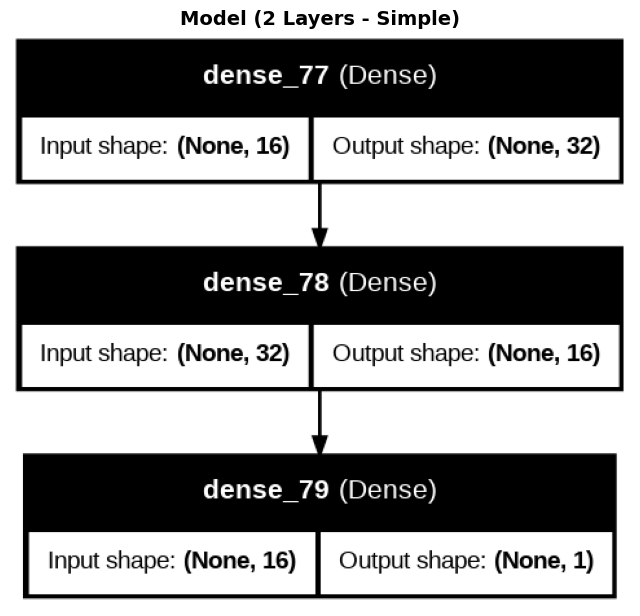

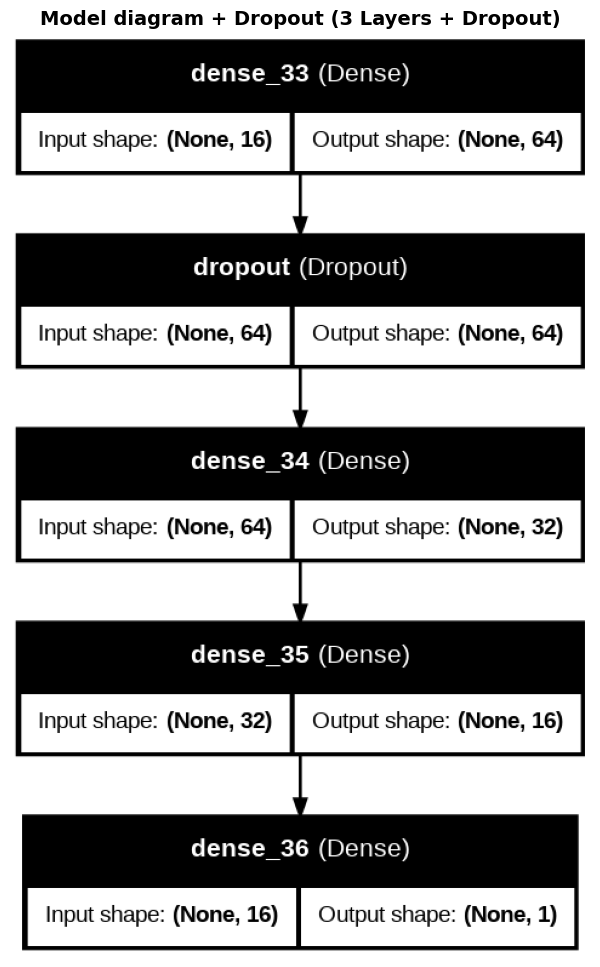

In [ ]:
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import os

# Auxiliar function
def mostrar_imagen(ruta, titulo):
    img = plt.imread(ruta)
    plt.figure(figsize=(8, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.show()

# MODEL 1
fichero1 = 'diagrama_modelo1_shallow.png'
plot_model(model_1,
           to_file=fichero1,
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB', dpi=96)
mostrar_imagen(fichero1, "Model (2 Layers - Simple)")

# MODEL 2
fichero2 = 'diagrama_modelo2_deep_dropout.png'
plot_model(model_2_single,
           to_file=fichero2,
           show_shapes=True,
           show_layer_names=True,
           # It shows Dropout box
           rankdir='TB', dpi=96)
mostrar_imagen(fichero2, "Model diagram + Dropout (3 Layers + Dropout)")


### 2.6.4. Validation.
**Accuracy based performance**

We start our validation by measuring the overall success rate of each model using raw accuracy.
This serves as a statistical baseline to ensure all architectures have correctly learned the general patterns of the dataset.

In [ ]:
scaler_global = StandardScaler()
X_scaled = scaler_global.fit_transform(X_train) # Train SI NO NO FUNCIONA


mlp_baseline.fit(X_train, y_train)

# evaluate
acc_base = mlp_baseline.score(X_test, y_test) * 100
print(f"Standard Baseline accuracy: {acc_base:.2f}%")

# Keras models (entrenados antes)
X_test_scaled = scaler_global.transform(X_test)
_, acc_k1 = model_1.evaluate(X_test_scaled, y_test, verbose=0)
_, acc_k2 = model_2_single.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Keras Model 1 accuracy:      {acc_k1*100:.2f}%")
print(f"Keras Model 2 accuracy:      {acc_k2*100:.2f}%")


Standard Baseline accuracy: 97.75%
Keras Model 1 accuracy:      96.70%
Keras Model 2 accuracy:      97.55%


**Cost based performance**

We evaluate the models using a clinical cost matrix that penalizes false negatives more heavily than false alarms.

In the 1.3. section of this Notebook we defined the cost matrix with `cost_loss_func `and then we put inside a Scikit-Learn box called `make_scorer` to make the cross validation automatical. Here we repeat the code for clarify the flow of the programming. We're using the library [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

In [ ]:
import pandas as pd

# SCALER
X_test_scaled = scaler_global.transform(X_test)

# PREDICTIONS
y_pred_base = mlp_baseline.predict(X_test)
y_pred_k1 = (model_1.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")
y_pred_k2 = (model_2_single.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")

# y_test
cost_base = clinical_cost_loss(y_test, y_pred_base)
cost_k1 = clinical_cost_loss(y_test, y_pred_k1)
cost_k2 = clinical_cost_loss(y_test, y_pred_k2)

# COMPARATION
results_df = pd.DataFrame({
    'Model': ['Baseline MLP', 'Keras Simple (Model 1)', 'Keras Deep+Dropout (Model 2)'],
    'Total clinical cost': [cost_base, cost_k1, cost_k2],
    'Mean cost per patient': [cost_base/len(y_test), cost_k1/len(y_test), cost_k2/len(y_test)]
})

print(results_df)

                          Model  Total clinical cost  Mean cost per patient
0                  Baseline MLP                  279                 0.1395
1        Keras Simple (Model 1)                  138                 0.0690
2  Keras Deep+Dropout (Model 2)                  337                 0.1685


#### Clinical costs

In [ ]:
import numpy as np

# SCIKIT LEARN ERROR
# training baseline here  because we have the error "NotFittedError"
mlp_baseline.fit(X_train, y_train)
y_pred_baseline = mlp_baseline.predict(X_test)
cost_baseline = clinical_cost_loss(y_test, y_pred_baseline)

# KERAS 2 LAYERS
# THRESHOLD 0.5
y_pred_1 = (model_1.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")
cost_model_1 = clinical_cost_loss(y_test, y_pred_1)

#KERAS 3-LAYERS + DROPOUT)
y_pred_2 = (model_2.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")
cost_model_2 = clinical_cost_loss(y_test, y_pred_2)

print(f"Standard Baseline: {cost_baseline} points")
print(f"Keras Model 1 (Cost-trained): {cost_model_1} points")
print(f"Keras Model 2 (Chosen Architecture): {cost_model_2} points")

Standard Baseline: 279 points
Keras Model 1 (Cost-trained): 138 points
Keras Model 2 (Chosen Architecture): 126 points


We use the following code for the cost matrix. We redefine some models/code because it gave us errors of the enviroment of programming. We made the code following [Seaborn Statistical data visualization](https://seaborn.pydata.org/)

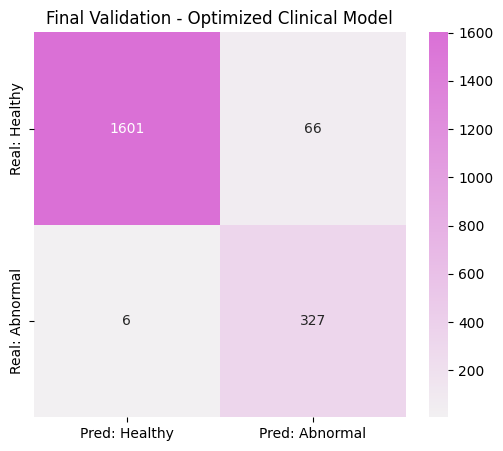

Sensitivity (Recall): 98.20%


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# In the Report of this project we explaing what is the winner model
# whe winner model for final validation is the second Model Cost Trained
# That's the model we use for this
y_pred_final = (model_2.predict(X_test_scaled, verbose=0) > 0.5).astype("int32")

## CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_rosita,
            xticklabels=['Pred: Healthy', 'Pred: Abnormal'],
            yticklabels=['Real: Healthy', 'Real: Abnormal'])
plt.title('Final Validation - Optimized Clinical Model')
plt.show()

# FOR SENSITIVITY
tp = cm[1,1]
fn = cm[1,0]
sensitivity = tp / (tp + fn)

print(f"Sensitivity (Recall): {sensitivity*100:.2f}%")



####Training Analysis: Learning Curves
Validation of the Keras model
Following teacher's notebook. To verify the reliability of our deep learning model, we plotted the learning curves for both accuracy and loss across the 50 training epochs. This visualization is essential to detect if the model is suffering from overfitting or underfitting

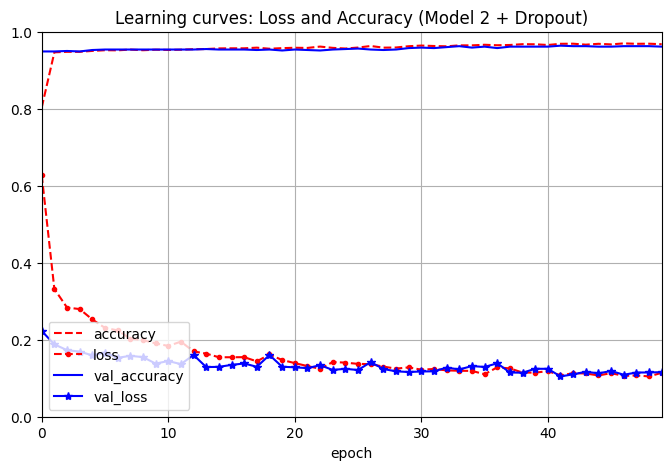

Graph generated


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# we use the history object from our model_2 training to see the learning curves
# this helps us check if dropout (0.3) is working against overfitting
pd.DataFrame(history_2.history).plot(
    figsize=(8, 5),
    xlim=[0, 49], # we set this to 49 because we used 50 epochs
    ylim=[0, 1],
    grid=True,
    xlabel="epoch",
    style=["r--", "r--.", "b-", "b-*"]
)

# adding a legend to know which line is training and which is validation
plt.legend(loc="lower left")
plt.title("Learning curves: Loss and Accuracy (Model 2 + Dropout)")
plt.show()

print("Graph generated")